# UBeauty Retail Perfomance
**Objective:** Analyze a recent 12-day sales (July 1st - 12th, 2026) across 19 branch locations to identify revenue drivers and optimize stock distribution.

## Phase 1: Data Loading & Header Rectification
The raw system export contains merged cells and date ranges in the first two rows. We must bypass these to access the true column headers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Importing the dataset we want to analyse
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/My Drive/Colab Notebooks/projects/"

#Load the CSSV into a Dataframe
data = pd.read_excel(PROJECT_DIR + "UBeauty-8.xlsx", header=3) # the header=2 variable is to skip the first 2 rows, this is because they are headings
data.head()

Mounted at /content/drive


,Item ID,Item Name,Foreign Name,Category Name,Unit,Spec,Onsale time,Junction Mall_Sales qty,Junction Mall_Sales Amt,Junction Mall_Stocks,...,Nord Mall_Last sale time,Greenwood Mall_Sales qty,Greenwood Mall_Sales Amt,Greenwood Mall_Stocks,Greenwood Mall_Last Buying Price,Greenwood Mall_First sale time,Greenwood Mall_Last sale time,Total sales qty,Total sales amt,Total stock qty
0,F010012,UBEAUTY Turmeric essence soap-100g,UBEAUTY 姜黄皂内含起泡网 100g,洁面皂(Cleansing soap),NaN,1*1*1,20/01/2025 13:17:16,4,1996,28,...,11/06/2026 19:28:17,3,1497,20,0,NaN,26/06/2026 13:37:31,94,46806.2,365
1,F050013,ubeauty TURMERIC antioxidant Cream -50g,UBEAUTY 姜黄面霜50g,面霜(cream),NaN,1*1*1,20/01/2025 13:17:16,1,629,28,...,28/06/2026 17:58:39,0,0,0,0,NaN,NaN,39,24342.3,399
2,F040020,ubeauty Collagen Serum -30ml,UBEAUTY 胶原蛋白精华 30ML,精华液(Essence),NaN,1*1*1,20/01/2025 13:17:16,12,8028,25,...,24/06/2026 15:48:14,7,4683,2,0,NaN,30/06/2026 20:05:36,107,71516.1,500
3,F040021,ubeauty VC Black Spot Remover Serum -30ML,UBEAUTY VC去斑精华30ML,精华液(Essence),NaN,1*1*1,20/01/2025 13:17:16,4,3076,29,...,25/06/2026 11:43:38,3,2307,11,0,NaN,17/06/2026 19:43:53,77,59213.0,352
4,F040018,ubeauty VC Black Spot Remover Serum -15ML,UBEAUTY VC去斑精华15ML,精华液(Essence),NaN,1*1*1,20/01/2025 13:17:16,15,7485,17,...,26/06/2026 18:17:56,3,1497,34,0,NaN,22/06/2026 16:31:35,90,44910.0,381


#Phase 2 : Removing the row (Total)
- This is because the last row called total is not a unique id so we have to drop it to avoid issues during calculations.

In [3]:
#dropping the last row
#data.drop(data.index[-1], inplace=True)
data = data[data['Item ID']!='Total'] # this means that we select all columns except column named Total this is called idempotent

# 2. Reset the index so the row numbers are perfectly sequential again
data.reset_index(drop=True, inplace=True)

#check the shape of the dataset now
data.shape

(77, 118)

## Phase 3: Branch Revenue Performance
**Objective:** Identify the highest-grossing branches during this 12-day snapshot to understand our primary revenue drivers.

Instead of manually calculating 19 separate locations, we will isolate all columns containing the phrase "Sales Amt" and aggregate them to reveal the top performers.

In [4]:
#we shall use a pandas function called filter to automatically grab the columns that have "sales amt" in there heading
branch_sales = data.filter(like= "Sales Amt")

#add each column, sort from highest to lowest
top_branches = branch_sales.sum().sort_values(ascending=False)
#show the top perfoming branches
print("Top 5 Performing Branches (Revenue):")
print(top_branches.head(5))

Top 5 Performing Branches (Revenue):
Sarit Centre_Sales Amt      183438.0
Two Rivers_Sales Amt        160257.0
Village Market_Sales Amt    154723.0
Junction Mall_Sales Amt     150452.0
Yaya Centre_Sales Amt       141593.0
dtype: float64


## Phase 4: Top Performing Products
**Objective:** Identify the highest-grossing individual products and their categories across the entire retail network.

In [5]:
#We grab the items names, categories and the total money they made
product_perfomance = data[["Item Name", "Category Name", "Total sales amt"]]
#sort them to find the biggest earners
top_products = product_perfomance.sort_values(by = "Total sales amt", ascending=False)
print("Top 5 Performing Products:")
print(top_products.head(5))

Top 5 Performing Products:
                                       Item Name      Category Name  \
15                   ubeauty Collagen Cream -51g          面霜(cream)   
13   ubeauty Salicyli acid anti-acne Serum -30ML       精华液(Essence)   
2                   ubeauty Collagen Serum -30ml       精华液(Essence)   
7     ubeauty Salicyli acid anti-acne Cream -50g          面霜(cream)   
74  UBEAUTY Collagen Vaseline Body Gel Oil 200ml  精油(Essential oil)   

    Total sales amt  
15         117008.1  
13          80638.4  
2           71516.1  
7           65361.3  
74          63852.0  


## Phase 6: Executive Visualizations
**Objective:** Translate data aggregations into visual business intelligence for stakeholder reporting.

/tmp/ipykernel_2105/3492366740.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_branches.head(5).values, y=branch_names, palette='viridis')


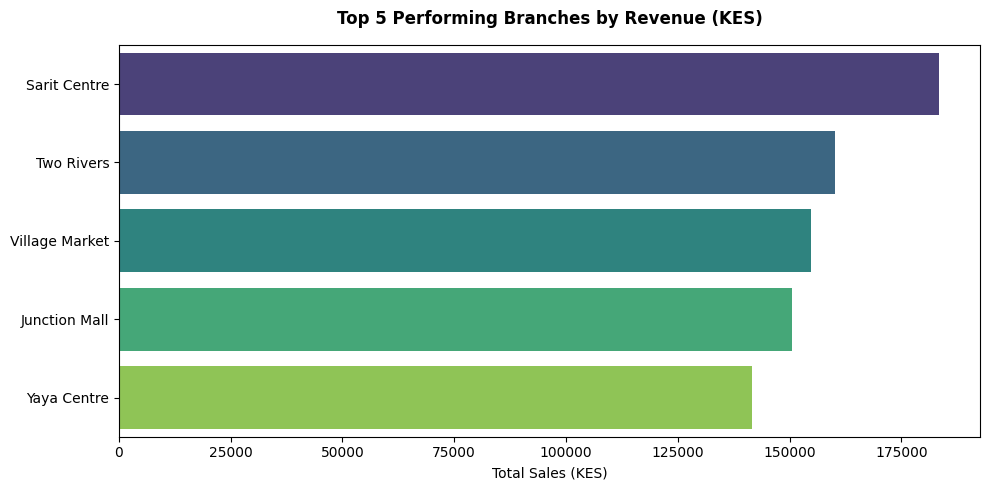

In [6]:
# Clean up the branch names (remove "_Sales Amt" so it looks good on the chart)
branch_names = [name.replace('_Sales Amt', '') for name in top_branches.head(5).index]

# Set up the canvas
plt.figure(figsize=(10, 5))

# Plot a horizontal bar chart
sns.barplot(x=top_branches.head(5).values, y=branch_names, palette='viridis')

# Add labels
plt.title('Top 5 Performing Branches by Revenue (KES)', pad=15, fontweight='bold')
plt.xlabel('Total Sales (KES)')
plt.ylabel('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2105/1312713369.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.head(5)['Total sales amt'].values, y=prod_names, palette='magma')


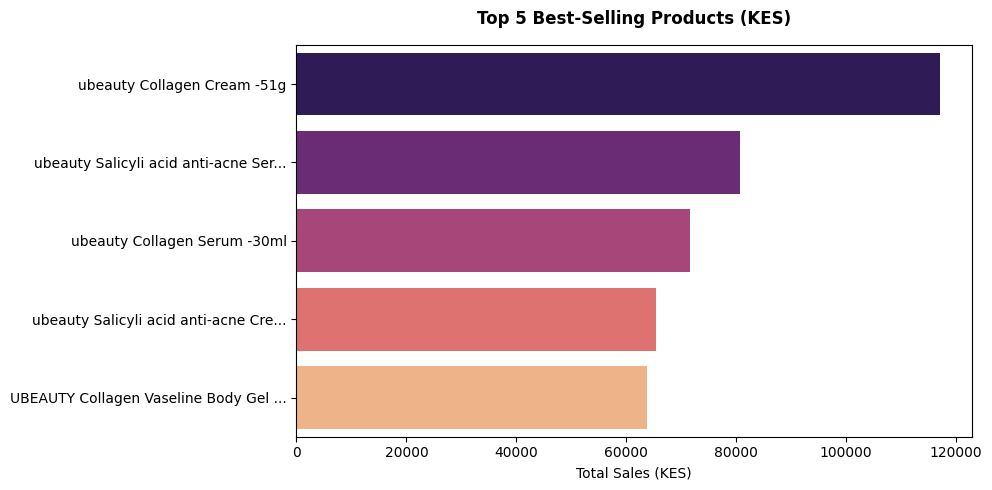

In [7]:
# Truncate long product names so they don't break the chart
prod_names = [name[:35] + '...' if len(name) > 35 else name for name in top_products.head(5)['Item Name']]

# Set up the canvas
plt.figure(figsize=(10, 5))

# Plot the chart using a different color palette
sns.barplot(x=top_products.head(5)['Total sales amt'].values, y=prod_names, palette='magma')

# Add labels
plt.title('Top 5 Best-Selling Products (KES)', pad=15, fontweight='bold')
plt.xlabel('Total Sales (KES)')
plt.ylabel('')
plt.tight_layout()
plt.show()